# 第5弾: HMM/GMMによるマーケットレジーム検出

## 戦略概要

- **HMMレジーム戦略**: 隠れマルコフモデル（GaussianHMM）でボラティリティ状態を自動分類し、状態ごとに戦略を切り替える手法
- 第4弾のADXはルールベースの相場環境認識。今回は確率モデルによる自動検出
- 特徴量: 5分足の対数リターン + ローリング標準偏差（ボラティリティ）

| 状態 | 特徴 | 戦略 |
|------|------|------|
| 低ボラ状態 | リターン小、ボラ小 → レンジ相場 | ミーンリバージョン（RSI逆張り） |
| 高ボラ状態 | リターン大、ボラ大 → トレンド相場 | ブレイクアウト（ドンチャン） |
| 中間状態（3状態時） | どちらとも言えない | ノーポジション |

## 検証対象

- USD/JPY（5分足、スプレッド片道0.002円）
- ETH/JPY（5分足、スプレッド片道=終値平均×0.00005）
- HMM 2状態 vs 3状態の比較も実施

## 1. セットアップ

In [1]:
!pip install japanize-matplotlib hmmlearn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 29.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 6.6 MB/s eta 0:00:00


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
from datetime import datetime, timedelta
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings('ignore')

import japanize_matplotlib

print("ライブラリ読み込み完了")

ライブラリ読み込み完了


## 2. GMO Coin KLine API からデータ取得

- FX（USD_JPY）は `priceType=BID` が必要
- 暗号資産（ETH_JPY）は `priceType` 不要

In [3]:
ENDPOINTS = {
    "fx":     "https://forex-api.coin.z.com/public/v1/klines",
    "crypto": "https://api.coin.z.com/public/v1/klines",
}

SYMBOL_CONFIG = {
    "USD_JPY": {"api": "fx",     "priceType": "BID"},
    "ETH_JPY": {"api": "crypto", "priceType": None},
}

def fetch_gmo_kline(symbol, interval="5min", days_back=365):
    config = SYMBOL_CONFIG.get(symbol)
    if config is None:
        print(f"未定義のシンボル: {symbol}")
        return pd.DataFrame()

    base_url = ENDPOINTS[config["api"]]
    all_data = []
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    current_date = start_date

    print(f"{symbol} の{interval}データを取得中...")
    print(f"  API: {config['api']} ({base_url})")
    print(f"  期間: {start_date.strftime('%Y-%m-%d')} -> {end_date.strftime('%Y-%m-%d')}")

    request_count = 0
    error_count = 0

    while current_date <= end_date:
        date_str = current_date.strftime("%Y%m%d")
        params = {"symbol": symbol, "interval": interval, "date": date_str}
        if config["priceType"]:
            params["priceType"] = config["priceType"]

        try:
            resp = requests.get(base_url, params=params, timeout=10)
            data = resp.json()
            if data.get("status") == 0 and data.get("data"):
                for c in data["data"]:
                    all_data.append({
                        "datetime": pd.to_datetime(
                            int(c["openTime"]), unit="ms", utc=True
                        ).tz_convert("Asia/Tokyo"),
                        "open":   float(c["open"]),
                        "high":   float(c["high"]),
                        "low":    float(c["low"]),
                        "close":  float(c["close"]),
                        "volume": float(c.get("volume", 0)),
                    })
                request_count += 1
        except Exception as e:
            error_count += 1
            if error_count <= 3:
                print(f"  {date_str}: {e}")

        current_date += timedelta(days=1)
        if request_count % 5 == 0 and request_count > 0:
            time.sleep(1)

    if not all_data:
        print(f"データ取得失敗: {symbol}")
        return pd.DataFrame()

    df = pd.DataFrame(all_data)
    df = df.sort_values("datetime").drop_duplicates(subset="datetime").reset_index(drop=True)

    print(f"{len(df):,}本取得 ({request_count}リクエスト)")
    print(f"  最初: {df['datetime'].iloc[0]}")
    print(f"  最後: {df['datetime'].iloc[-1]}")
    return df

print("データ取得関数を定義")

データ取得関数を定義


### USD/JPY データ取得

In [4]:
df_usdjpy = fetch_gmo_kline("USD_JPY", interval="5min", days_back=365)
df_usdjpy.head()

USD_JPY の5minデータを取得中...
  API: fx (https://forex-api.coin.z.com/public/v1/klines)
  期間: 2025-04-08 -> 2026-04-08
73,983本取得 (260リクエスト)
  最初: 2025-04-08 06:00:00+09:00
  最後: 2026-04-08 10:25:00+09:00


,datetime,open,high,low,close,volume
0,2025-04-08 06:00:00+09:00,147.785,147.895,147.785,147.862,0.0
1,2025-04-08 06:05:00+09:00,147.862,147.886,147.862,147.882,0.0
2,2025-04-08 06:10:00+09:00,147.882,147.884,147.880,147.880,0.0
3,2025-04-08 06:15:00+09:00,147.880,147.884,147.850,147.852,0.0
4,2025-04-08 06:20:00+09:00,147.852,147.876,147.850,147.872,0.0


### ETH/JPY データ取得

In [5]:
df_eth = fetch_gmo_kline("ETH_JPY", interval="5min", days_back=365)
df_eth.head()

ETH_JPY の5minデータを取得中...
  API: crypto (https://api.coin.z.com/public/v1/klines)
  期間: 2025-04-08 -> 2026-04-08
103,184本取得 (366リクエスト)
  最初: 2025-04-08 06:00:00+09:00
  最後: 2026-04-08 10:30:00+09:00


,datetime,open,high,low,close,volume
0,2025-04-08 06:00:00+09:00,232174.0,232280.0,231400.0,231451.0,41.28
1,2025-04-08 06:05:00+09:00,231434.0,231475.0,230360.0,230967.0,18.08
2,2025-04-08 06:10:00+09:00,231182.0,231815.0,231182.0,231815.0,6.46
3,2025-04-08 06:15:00+09:00,231867.0,232290.0,231621.0,232181.0,6.90
4,2025-04-08 06:20:00+09:00,232134.0,232135.0,230725.0,231187.0,12.48


## 3. テクニカル指標の計算

### HMMの特徴量

GaussianHMMに渡す特徴量として以下の2つを使用する。

- **対数リターン**: `log(close_t / close_{t-1})` — 価格変動の方向と大きさ
- **ローリング標準偏差**: 対数リターンの直近24本（2時間）の標準偏差 — ボラティリティの水準

この2次元の特徴量空間でHMMが状態を自動分類する。状態の解釈（低ボラ/高ボラ）は、各状態のボラ平均値を見て事後的に決定する。

### 売買指標（状態別に使用）

- **RSI**: ミーンリバージョン用（低ボラ状態）
- **ドンチャンチャネル**: ブレイクアウト用（高ボラ状態）

In [6]:
def calc_rsi(series, period=14):
    """RSIを計算（Wilder's smoothing）"""
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period).mean()
    rs  = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def add_hmm_indicators(df, rsi_period=14, dc_period=20, vol_window=24):
    """HMM戦略用の指標をDataFrameに追加"""
    df = df.copy()

    # HMM特徴量
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))
    df["volatility"] = df["log_return"].rolling(window=vol_window).std()

    # 売買指標
    df["rsi"]            = calc_rsi(df["close"], period=rsi_period)
    df["dc_upper"]       = df["high"].rolling(window=dc_period).max()
    df["dc_lower"]       = df["low"].rolling(window=dc_period).min()
    df["dc_exit_upper"]  = df["high"].rolling(window=dc_period // 2).max()
    df["dc_exit_lower"]  = df["low"].rolling(window=dc_period // 2).min()

    return df.dropna().reset_index(drop=True)


df_usdjpy = add_hmm_indicators(df_usdjpy)
df_eth    = add_hmm_indicators(df_eth)

print(f"USD/JPY: {len(df_usdjpy):,}本（指標計算後）")
print(f"ETH/JPY: {len(df_eth):,}本（指標計算後）")

USD/JPY: 73,959本（指標計算後）
ETH/JPY: 103,160本（指標計算後）


## 4. HMMによるレジーム検出

GaussianHMMで状態を学習し、各バーにレジームラベルを付与する。
状態番号は学習のたびに変わるため、ボラティリティ平均値でソートして
「状態0=低ボラ、状態1=高ボラ（、状態2=超高ボラ）」に統一する。

In [9]:
def fit_hmm(df, n_states=2, n_iter=200, random_state=42):
    """
    GaussianHMMを学習してレジームラベルを返す。
    状態はボラティリティ平均でソートし、0=低ボラ、n-1=高ボラに統一。
    """
    features_raw = df[["log_return", "volatility"]].to_numpy()

    # 標準化（共分散行列の数値的安定性を確保）
    mean = features_raw.mean(axis=0)
    std  = features_raw.std(axis=0) + 1e-10
    features = (features_raw - mean) / std

    model = GaussianHMM(
        n_components=n_states,
        covariance_type="diag",   # fullだと特異になりやすいのでdiagに変更
        n_iter=n_iter,
        random_state=random_state
    )
    model.fit(features)
    raw_states = model.predict(features)

    # ボラティリティ平均でソート（低ボラ=0, 高ボラ=n-1）
    vol_means = [
        df["volatility"].iloc[raw_states == s].mean()
        for s in range(n_states)
    ]
    order = np.argsort(vol_means)
    remap = {old: new for new, old in enumerate(order)}
    states = np.array([remap[s] for s in raw_states])

    # 状態ごとの統計を表示
    print(f"\nHMM {n_states}状態 — 状態別統計:")
    labels = ["低ボラ", "中間", "高ボラ"] if n_states == 3 else ["低ボラ", "高ボラ"]
    for s in range(n_states):
        mask = states == s
        vol_m = df["volatility"].iloc[mask].mean()
        ret_m = df["log_return"].iloc[mask].mean()
        pct   = mask.mean() * 100
        print(f"  状態{s} ({labels[s]}): {pct:.1f}%  ボラ平均={vol_m:.6f}  リターン平均={ret_m:.6f}")

    return states, model

print("HMM学習関数を定義")

HMM学習関数を定義


### USD/JPY レジーム検出（2状態 / 3状態）

In [10]:
print("=== USD/JPY ===")
states_usdjpy_2, model_usdjpy_2 = fit_hmm(df_usdjpy, n_states=2)
states_usdjpy_3, model_usdjpy_3 = fit_hmm(df_usdjpy, n_states=3)

df_usdjpy["regime_2"] = states_usdjpy_2
df_usdjpy["regime_3"] = states_usdjpy_3

=== USD/JPY ===

HMM 2状態 — 状態別統計:
  状態0 (低ボラ): 70.5%  ボラ平均=0.000212  リターン平均=0.000002
  状態1 (高ボラ): 29.5%  ボラ平均=0.000471  リターン平均=-0.000001

HMM 3状態 — 状態別統計:
  状態0 (低ボラ): 40.2%  ボラ平均=0.000169  リターン平均=0.000002
  状態1 (中間): 41.3%  ボラ平均=0.000289  リターン平均=0.000001
  状態2 (高ボラ): 18.5%  ボラ平均=0.000546  リターン平均=-0.000001


### ETH/JPY レジーム検出（2状態 / 3状態）

In [11]:
print("=== ETH/JPY ===")
states_eth_2, model_eth_2 = fit_hmm(df_eth, n_states=2)
states_eth_3, model_eth_3 = fit_hmm(df_eth, n_states=3)

df_eth["regime_2"] = states_eth_2
df_eth["regime_3"] = states_eth_3

=== ETH/JPY ===

HMM 2状態 — 状態別統計:
  状態0 (低ボラ): 64.9%  ボラ平均=0.001299  リターン平均=0.000004
  状態1 (高ボラ): 35.1%  ボラ平均=0.003025  リターン平均=0.000003

HMM 3状態 — 状態別統計:
  状態0 (低ボラ): 38.9%  ボラ平均=0.001032  リターン平均=0.000005
  状態1 (中間): 39.2%  ボラ平均=0.001864  リターン平均=-0.000005
  状態2 (高ボラ): 21.9%  ボラ平均=0.003530  リターン平均=0.000019


## 5. バックテスト

In [12]:
def backtest_hmm_regime(
    df,
    regime_col="regime_2",
    n_states=2,
    rsi_oversold=30,
    rsi_overbought=70,
    spread=0.0,
    symbol_name=""
):
    """
    HMMレジーム戦略のバックテスト（numpy配列化で高速化）。

    2状態:
      状態0（低ボラ）: ミーンリバージョン（RSI逆張り）
      状態1（高ボラ）: ブレイクアウト（ドンチャン）
    3状態:
      状態0（低ボラ）: ミーンリバージョン
      状態1（中間）  : ノーポジション
      状態2（高ボラ）: ブレイクアウト
    """
    close       = df["close"].to_numpy()
    rsi         = df["rsi"].to_numpy()
    regime      = df[regime_col].to_numpy()
    dc_upper    = df["dc_upper"].to_numpy()
    dc_lower    = df["dc_lower"].to_numpy()
    dc_ex_upper = df["dc_exit_upper"].to_numpy()
    dc_ex_lower = df["dc_exit_lower"].to_numpy()
    datetimes   = df["datetime"].to_numpy()

    high_vol_state = n_states - 1  # 高ボラ状態のラベル

    position    = 0
    entry_price = 0.0
    entry_time  = None
    entry_mode  = ""
    trades      = []
    equity      = 0.0
    equity_curve = [0.0]

    for i in range(1, len(close)):
        c   = close[i]
        r   = rsi[i]
        reg = regime[i]
        prev_dc_up  = dc_upper[i - 1]
        prev_dc_low = dc_lower[i - 1]
        prev_ex_up  = dc_ex_upper[i - 1]
        prev_ex_low = dc_ex_lower[i - 1]

        is_low_vol  = (reg == 0)
        is_high_vol = (reg == high_vol_state)
        # 中間状態（3状態時）はエントリーしない

        # --- エントリー ---
        if position == 0:
            if is_low_vol:
                if r < rsi_oversold:
                    position    = 1
                    entry_price = c + spread
                    entry_time  = datetimes[i]
                    entry_mode  = "mean_rev"
                elif r > rsi_overbought:
                    position    = -1
                    entry_price = c - spread
                    entry_time  = datetimes[i]
                    entry_mode  = "mean_rev"
            elif is_high_vol:
                if c > prev_dc_up:
                    position    = 1
                    entry_price = c + spread
                    entry_time  = datetimes[i]
                    entry_mode  = "breakout"
                elif c < prev_dc_low:
                    position    = -1
                    entry_price = c - spread
                    entry_time  = datetimes[i]
                    entry_mode  = "breakout"

        # --- エグジット ---
        elif position == 1:
            exit_signal = (
                (entry_mode == "mean_rev"  and r > 50) or
                (entry_mode == "breakout" and c < prev_ex_low)
            )
            if exit_signal:
                exit_price = c - spread
                pnl = exit_price - entry_price
                trades.append({
                    "entry_time": entry_time, "exit_time": datetimes[i],
                    "direction": "LONG", "mode": entry_mode,
                    "entry_price": entry_price, "exit_price": exit_price,
                    "pnl": pnl, "pnl_pct": pnl / entry_price * 100,
                })
                equity  += pnl
                position = 0

        elif position == -1:
            exit_signal = (
                (entry_mode == "mean_rev"  and r < 50) or
                (entry_mode == "breakout" and c > prev_ex_up)
            )
            if exit_signal:
                exit_price = c + spread
                pnl = entry_price - exit_price
                trades.append({
                    "entry_time": entry_time, "exit_time": datetimes[i],
                    "direction": "SHORT", "mode": entry_mode,
                    "entry_price": entry_price, "exit_price": exit_price,
                    "pnl": pnl, "pnl_pct": pnl / entry_price * 100,
                })
                equity  += pnl
                position = 0

        equity_curve.append(equity)

    # --- 集計 ---
    if not trades:
        print(f"{symbol_name}: トレード0件")
        return {"trades_df": pd.DataFrame(), "equity_curve": equity_curve,
                "total_trades": 0, "symbol": symbol_name}

    tdf = pd.DataFrame(trades)
    wins   = tdf[tdf["pnl"] > 0]
    losses = tdf[tdf["pnl"] <= 0]
    gp = wins["pnl"].sum()        if len(wins)   else 0
    gl = abs(losses["pnl"].sum()) if len(losses) else 0
    pf = gp / gl if gl > 0 else float("inf")
    eq = pd.Series(equity_curve)
    max_dd = (eq - eq.cummax()).min()
    sharpe = (
        tdf["pnl_pct"].mean() / tdf["pnl_pct"].std() * np.sqrt(len(tdf))
        if len(tdf) > 1 and tdf["pnl_pct"].std() > 0 else 0.0
    )
    hold_bars = (
        pd.to_datetime(tdf["exit_time"]) - pd.to_datetime(tdf["entry_time"])
    ).dt.total_seconds() / 300

    mr = tdf[tdf["mode"] == "mean_rev"]
    bo = tdf[tdf["mode"] == "breakout"]

    res = {
        "symbol": symbol_name, "total_trades": len(tdf),
        "wins": len(wins), "losses": len(losses),
        "win_rate": len(wins) / len(tdf) * 100,
        "total_pnl": tdf["pnl"].sum(), "avg_pnl": tdf["pnl"].mean(),
        "profit_factor": pf, "max_drawdown": max_dd,
        "sharpe_ratio": sharpe, "avg_hold_bars": hold_bars.mean(),
        "trades_df": tdf, "equity_curve": equity_curve,
        "mean_rev_trades": len(mr), "breakout_trades": len(bo),
    }

    print(f"\n{'='*55}")
    print(f"{symbol_name} HMMレジーム戦略 ({n_states}状態)")
    print(f"{'='*55}")
    print(f"  トレード数      : {res['total_trades']} (MR:{res['mean_rev_trades']} / BO:{res['breakout_trades']})")
    print(f"  勝ち / 負け     : {res['wins']} / {res['losses']}")
    print(f"  勝率            : {res['win_rate']:.1f}%")
    print(f"  総損益          : {res['total_pnl']:.4f}")
    print(f"  平均損益        : {res['avg_pnl']:.4f}")
    print(f"  PF              : {res['profit_factor']:.3f}")
    print(f"  最大DD          : {res['max_drawdown']:.4f}")
    print(f"  シャープレシオ  : {res['sharpe_ratio']:.3f}")
    print(f"  平均保有        : {res['avg_hold_bars']:.0f}本（={res['avg_hold_bars']*5:.0f}分）")
    print(f"{'='*55}")
    return res

print("バックテスト関数を定義")

バックテスト関数を定義


### USD/JPY バックテスト（2状態 / 3状態）

In [13]:
results_usdjpy_2 = backtest_hmm_regime(
    df_usdjpy, regime_col="regime_2", n_states=2,
    spread=0.002, symbol_name="USD/JPY"
)
results_usdjpy_3 = backtest_hmm_regime(
    df_usdjpy, regime_col="regime_3", n_states=3,
    spread=0.002, symbol_name="USD/JPY"
)


USD/JPY HMMレジーム戦略 (2状態)
  トレード数      : 1390 (MR:642 / BO:748)
  勝ち / 負け     : 693 / 697
  勝率            : 49.9%
  総損益          : -12.5860
  平均損益        : -0.0091
  PF              : 0.905
  最大DD          : -18.8810
  シャープレシオ  : -1.227
  平均保有        : 31本（=153分）

USD/JPY HMMレジーム戦略 (3状態)
  トレード数      : 945 (MR:435 / BO:510)
  勝ち / 負け     : 487 / 458
  勝率            : 51.5%
  総損益          : -2.1330
  平均損益        : -0.0023
  PF              : 0.976
  最大DD          : -11.7950
  シャープレシオ  : -0.238
  平均保有        : 32本（=162分）


### ETH/JPY バックテスト（2状態 / 3状態）

In [14]:
eth_spread = df_eth["close"].mean() * 0.00005
print(f"ETH/JPY 推定スプレッド: {eth_spread:.0f}円")

results_eth_2 = backtest_hmm_regime(
    df_eth, regime_col="regime_2", n_states=2,
    spread=eth_spread, symbol_name="ETH/JPY"
)
results_eth_3 = backtest_hmm_regime(
    df_eth, regime_col="regime_3", n_states=3,
    spread=eth_spread, symbol_name="ETH/JPY"
)

ETH/JPY 推定スプレッド: 23円

ETH/JPY HMMレジーム戦略 (2状態)
  トレード数      : 1951 (MR:708 / BO:1243)
  勝ち / 負け     : 884 / 1067
  勝率            : 45.3%
  総損益          : -584331.5259
  平均損益        : -299.5036
  PF              : 0.844
  最大DD          : -663840.3435
  シャープレシオ  : -2.512
  平均保有        : 23本（=113分）

ETH/JPY HMMレジーム戦略 (3状態)
  トレード数      : 1306 (MR:474 / BO:832)
  勝ち / 負け     : 627 / 679
  勝率            : 48.0%
  総損益          : -117426.9707
  平均損益        : -89.9135
  PF              : 0.954
  最大DD          : -293401.8126
  シャープレシオ  : -0.768
  平均保有        : 23本（=116分）


## 6. 結果の可視化

In [15]:
def plot_hmm_regime_results(results, df, regime_col, n_states, label=""):
    """HMMレジーム戦略の結果を4分割チャート + 月別損益で可視化"""
    tdf = results["trades_df"]
    if tdf.empty:
        print("トレード0件のためスキップ")
        return
    symbol = results["symbol"]

    regime_colors = ["#a8d8ea", "#f9d4d4", "#ffd580"]  # 低ボラ=青, 高ボラ=赤, 中間=黄
    regime_labels = ["低ボラ(MR)", "高ボラ(BO)"] if n_states == 2 else ["低ボラ(MR)", "中間(待機)", "高ボラ(BO)"]

    fig, axes = plt.subplots(4, 1, figsize=(16, 16),
                             gridspec_kw={"height_ratios": [3, 1, 1, 2]})
    fig.suptitle(f"{symbol} HMMレジーム戦略 {n_states}状態 {label}",
                 fontsize=16, fontweight="bold")

    # 価格 + レジーム背景色 + エントリーポイント
    ax = axes[0]
    regime_arr = df[regime_col].to_numpy()
    dt_arr     = df["datetime"].to_numpy()
    for s in range(n_states):
        mask = regime_arr == s
        ax.fill_between(dt_arr, df["close"].min(), df["close"].max(),
                        where=mask, alpha=0.15, color=regime_colors[s],
                        label=regime_labels[s])
    ax.plot(df["datetime"], df["close"], color="black", lw=0.5, alpha=0.9)
    mr  = tdf[tdf["mode"] == "mean_rev"]
    bo  = tdf[tdf["mode"] == "breakout"]
    if len(mr[mr["direction"] == "LONG"]):
        ax.scatter(mr[mr["direction"] == "LONG"]["entry_time"],
                   mr[mr["direction"] == "LONG"]["entry_price"],
                   marker="^", color="green", s=25, alpha=0.8, zorder=5, label="MR Long")
    if len(mr[mr["direction"] == "SHORT"]):
        ax.scatter(mr[mr["direction"] == "SHORT"]["entry_time"],
                   mr[mr["direction"] == "SHORT"]["entry_price"],
                   marker="v", color="red", s=25, alpha=0.8, zorder=5, label="MR Short")
    if len(bo[bo["direction"] == "LONG"]):
        ax.scatter(bo[bo["direction"] == "LONG"]["entry_time"],
                   bo[bo["direction"] == "LONG"]["entry_price"],
                   marker="^", color="blue", s=25, alpha=0.8, zorder=5, label="BO Long")
    if len(bo[bo["direction"] == "SHORT"]):
        ax.scatter(bo[bo["direction"] == "SHORT"]["entry_time"],
                   bo[bo["direction"] == "SHORT"]["entry_price"],
                   marker="v", color="orange", s=25, alpha=0.8, zorder=5, label="BO Short")
    ax.legend(loc="upper left", fontsize=7)
    ax.set_ylabel("Price")
    ax.set_title("価格 + HMMレジーム（背景色）+ エントリーポイント")

    # ボラティリティ + レジームラベル
    ax = axes[1]
    ax.plot(df["datetime"], df["volatility"], color="purple", lw=0.5, label="Volatility")
    for s in range(n_states):
        mask = regime_arr == s
        ax.fill_between(dt_arr, 0, df["volatility"].max(),
                        where=mask, alpha=0.15, color=regime_colors[s])
    ax.legend(loc="upper left", fontsize=7)
    ax.set_ylabel("Volatility")
    ax.set_title("ローリングボラティリティ + HMMレジーム")

    # 各トレードPnL
    ax = axes[2]
    colors = ["green" if p > 0 else "red" for p in tdf["pnl"]]
    ax.bar(range(len(tdf)), tdf["pnl"], color=colors, alpha=0.7)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("PnL")
    ax.set_xlabel("Trade #")
    ax.set_title("各トレード損益")

    # エクイティカーブ
    ax = axes[3]
    eq = results["equity_curve"]
    ax.plot(eq, color="navy", lw=1)
    ax.fill_between(range(len(eq)), eq, alpha=0.1, color="navy")
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_ylabel("累積損益")
    ax.set_xlabel("Bar")
    ax.set_title("エクイティカーブ")

    plt.tight_layout()
    plt.show()

    # 月別損益
    tdf2 = tdf.copy()
    tdf2["month"] = pd.to_datetime(tdf2["entry_time"]).dt.to_period("M")
    monthly = tdf2.groupby("month")["pnl"].sum()
    if len(monthly) > 1:
        fig2, ax2 = plt.subplots(figsize=(14, 3))
        mc = ["green" if v > 0 else "red" for v in monthly.values]
        ax2.bar(range(len(monthly)), monthly.values, color=mc, alpha=0.7)
        ax2.set_xticks(range(len(monthly)))
        ax2.set_xticklabels([str(m) for m in monthly.index], rotation=45, fontsize=8)
        ax2.axhline(0, color="black", lw=0.5)
        ax2.set_title(f"{symbol} 月別損益 {n_states}状態 {label}")
        ax2.set_ylabel("PnL")
        plt.tight_layout()
        plt.show()

print("可視化関数を定義")

可視化関数を定義


### USD/JPY 結果（2状態）

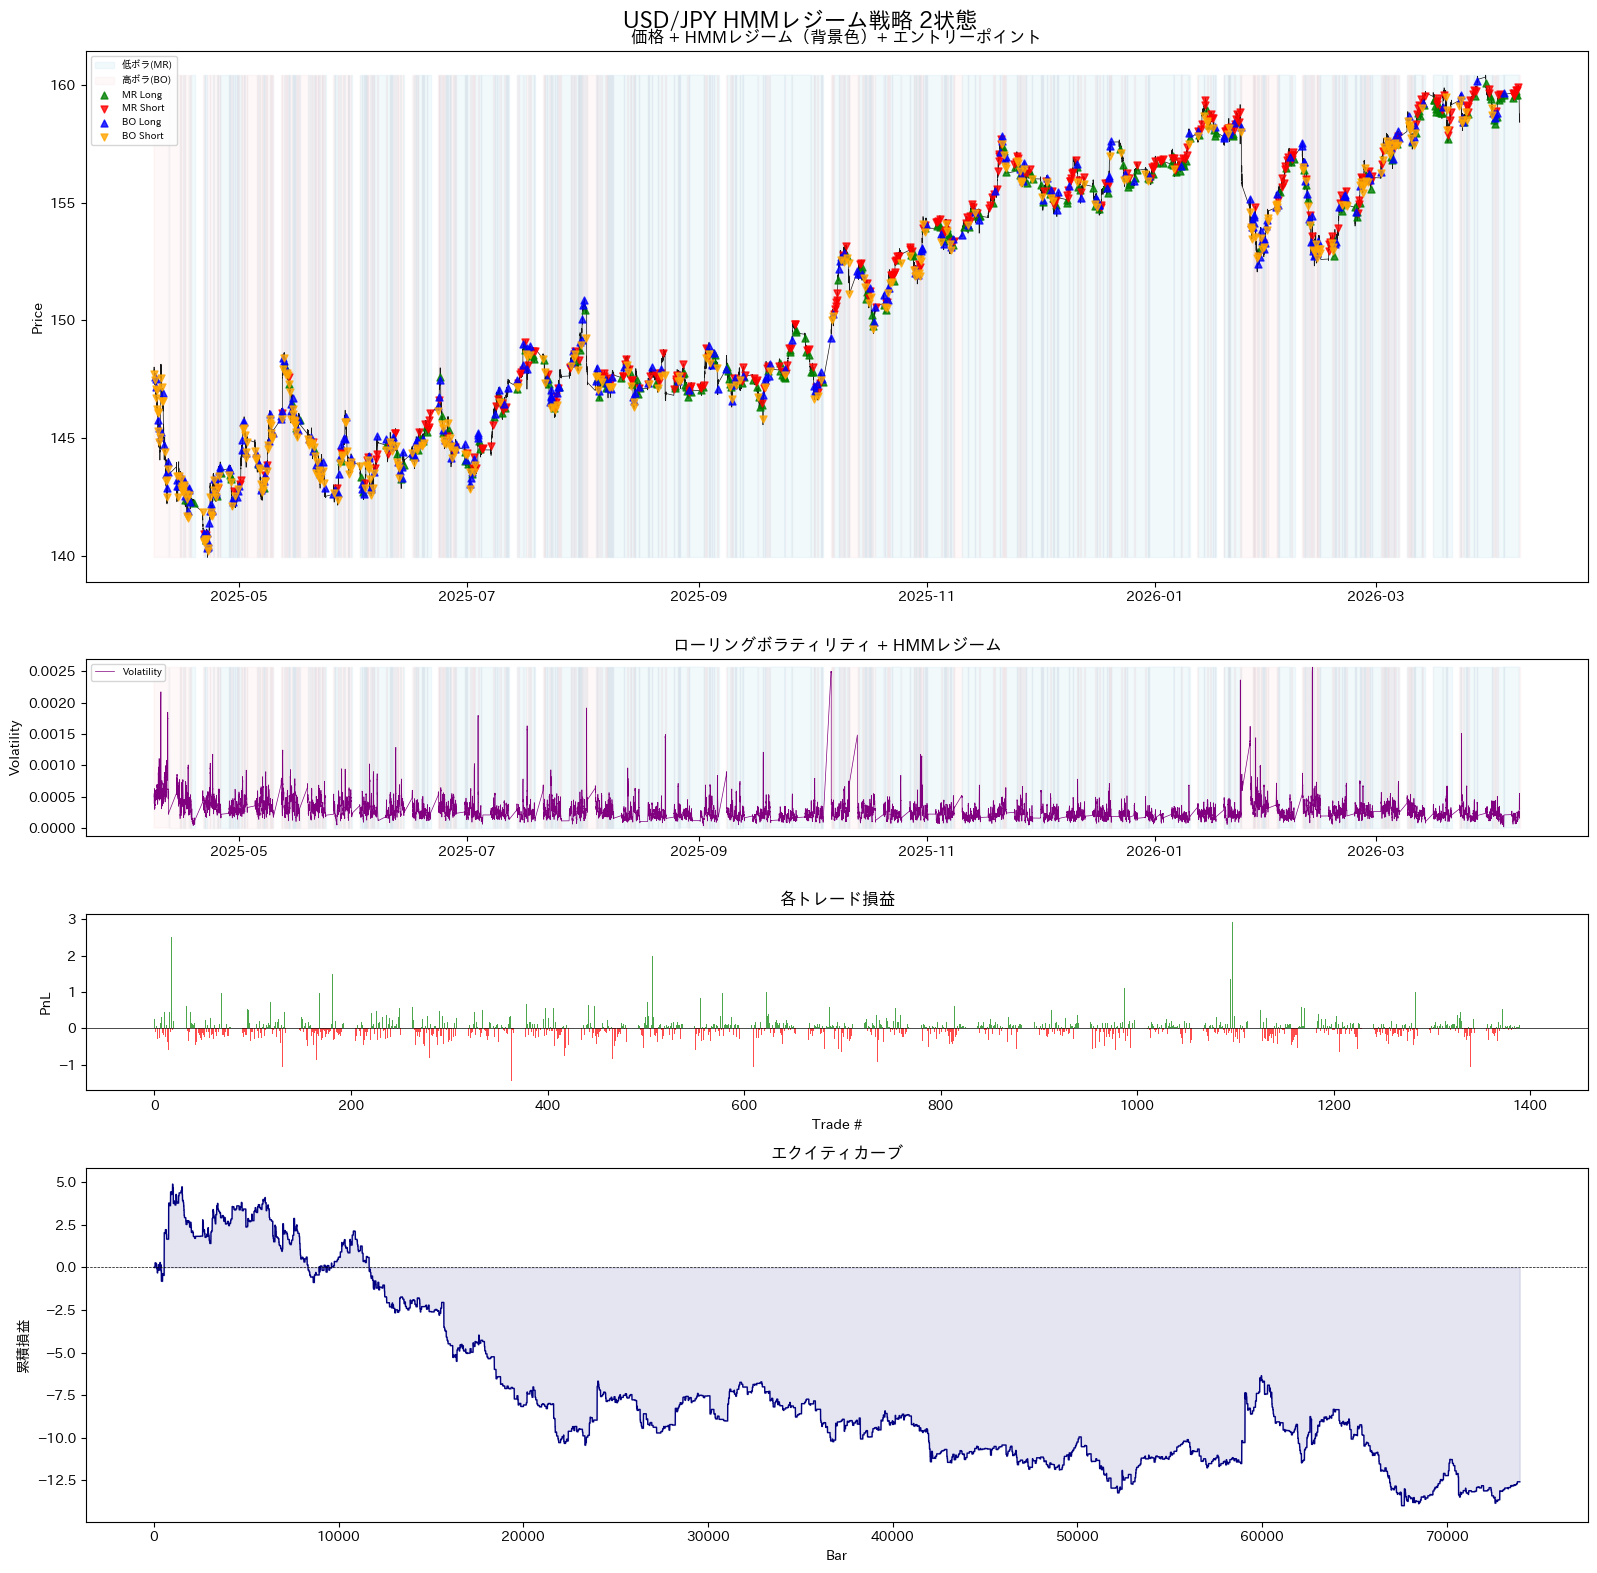

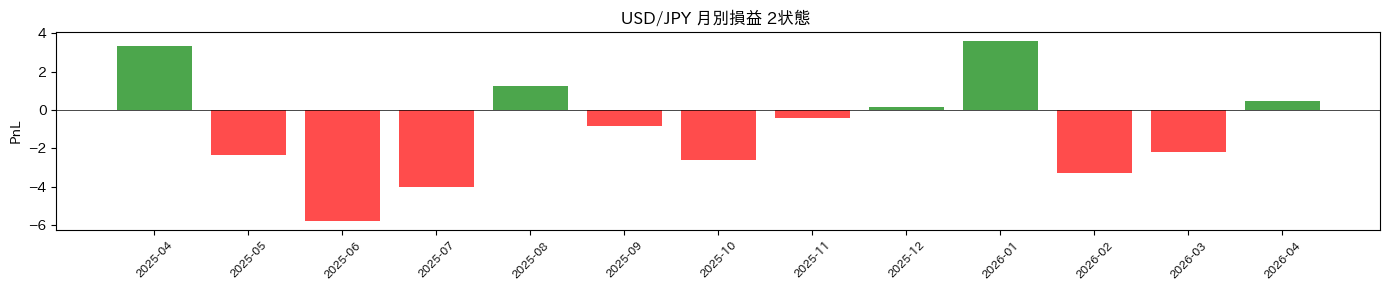

In [16]:
plot_hmm_regime_results(results_usdjpy_2, df_usdjpy, "regime_2", n_states=2)

### USD/JPY 結果（3状態）

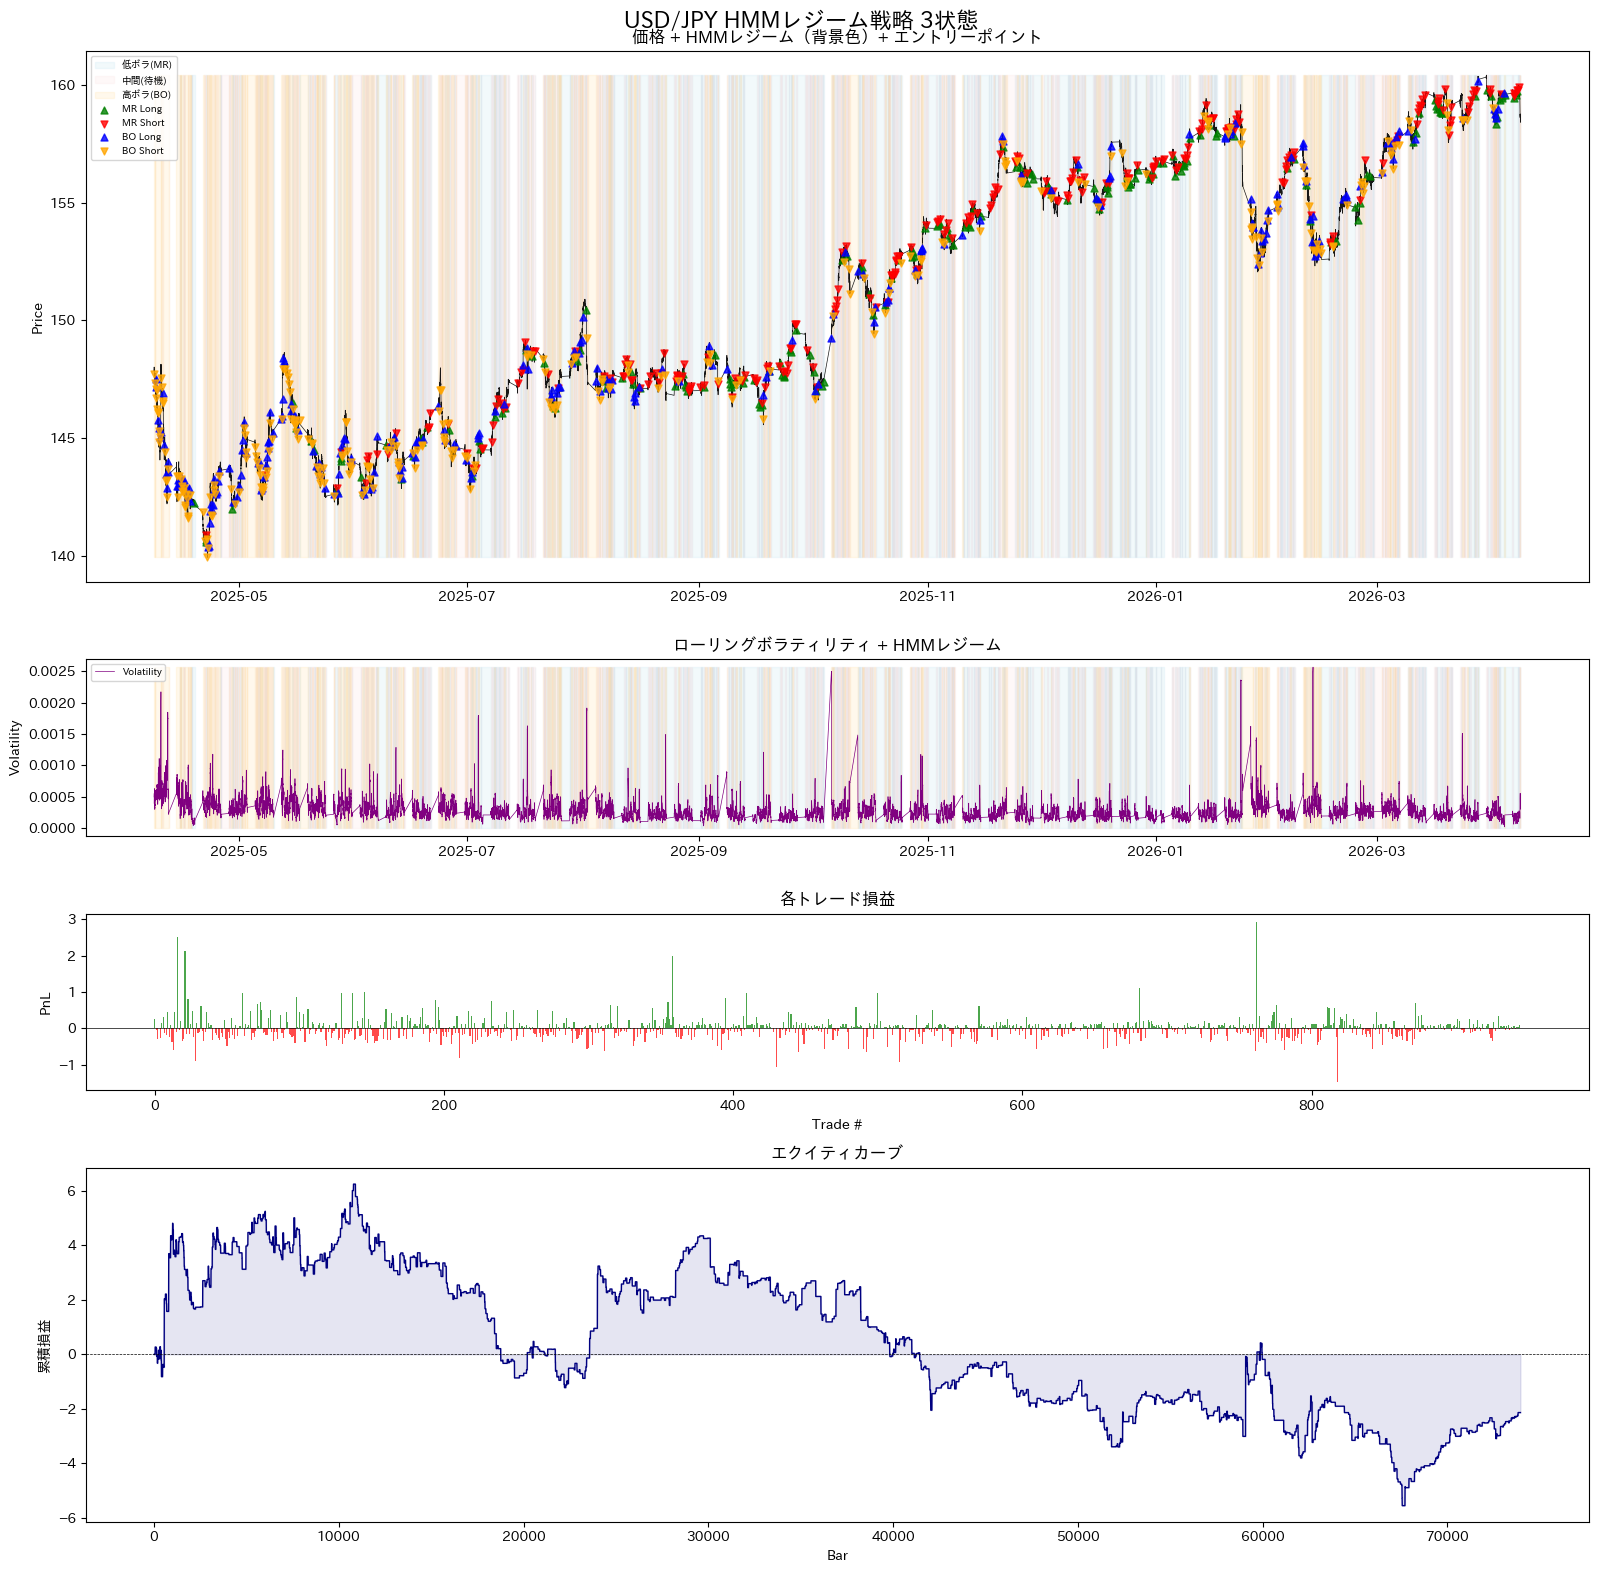

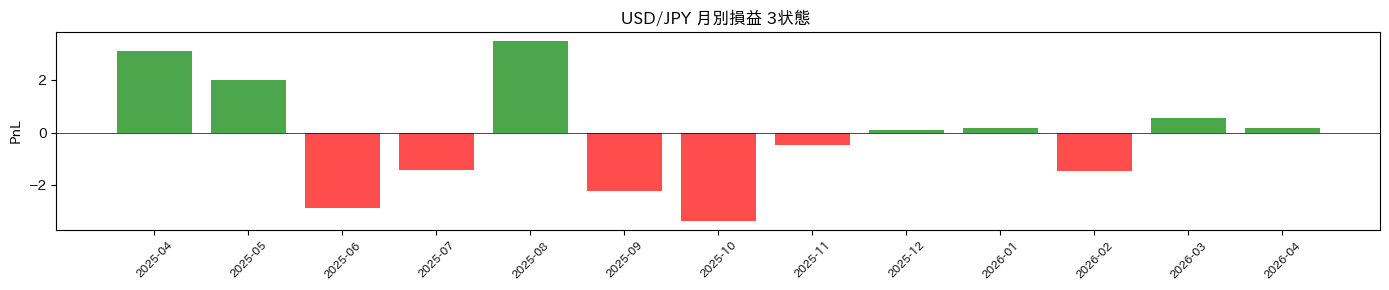

In [17]:
plot_hmm_regime_results(results_usdjpy_3, df_usdjpy, "regime_3", n_states=3)

### ETH/JPY 結果（2状態）

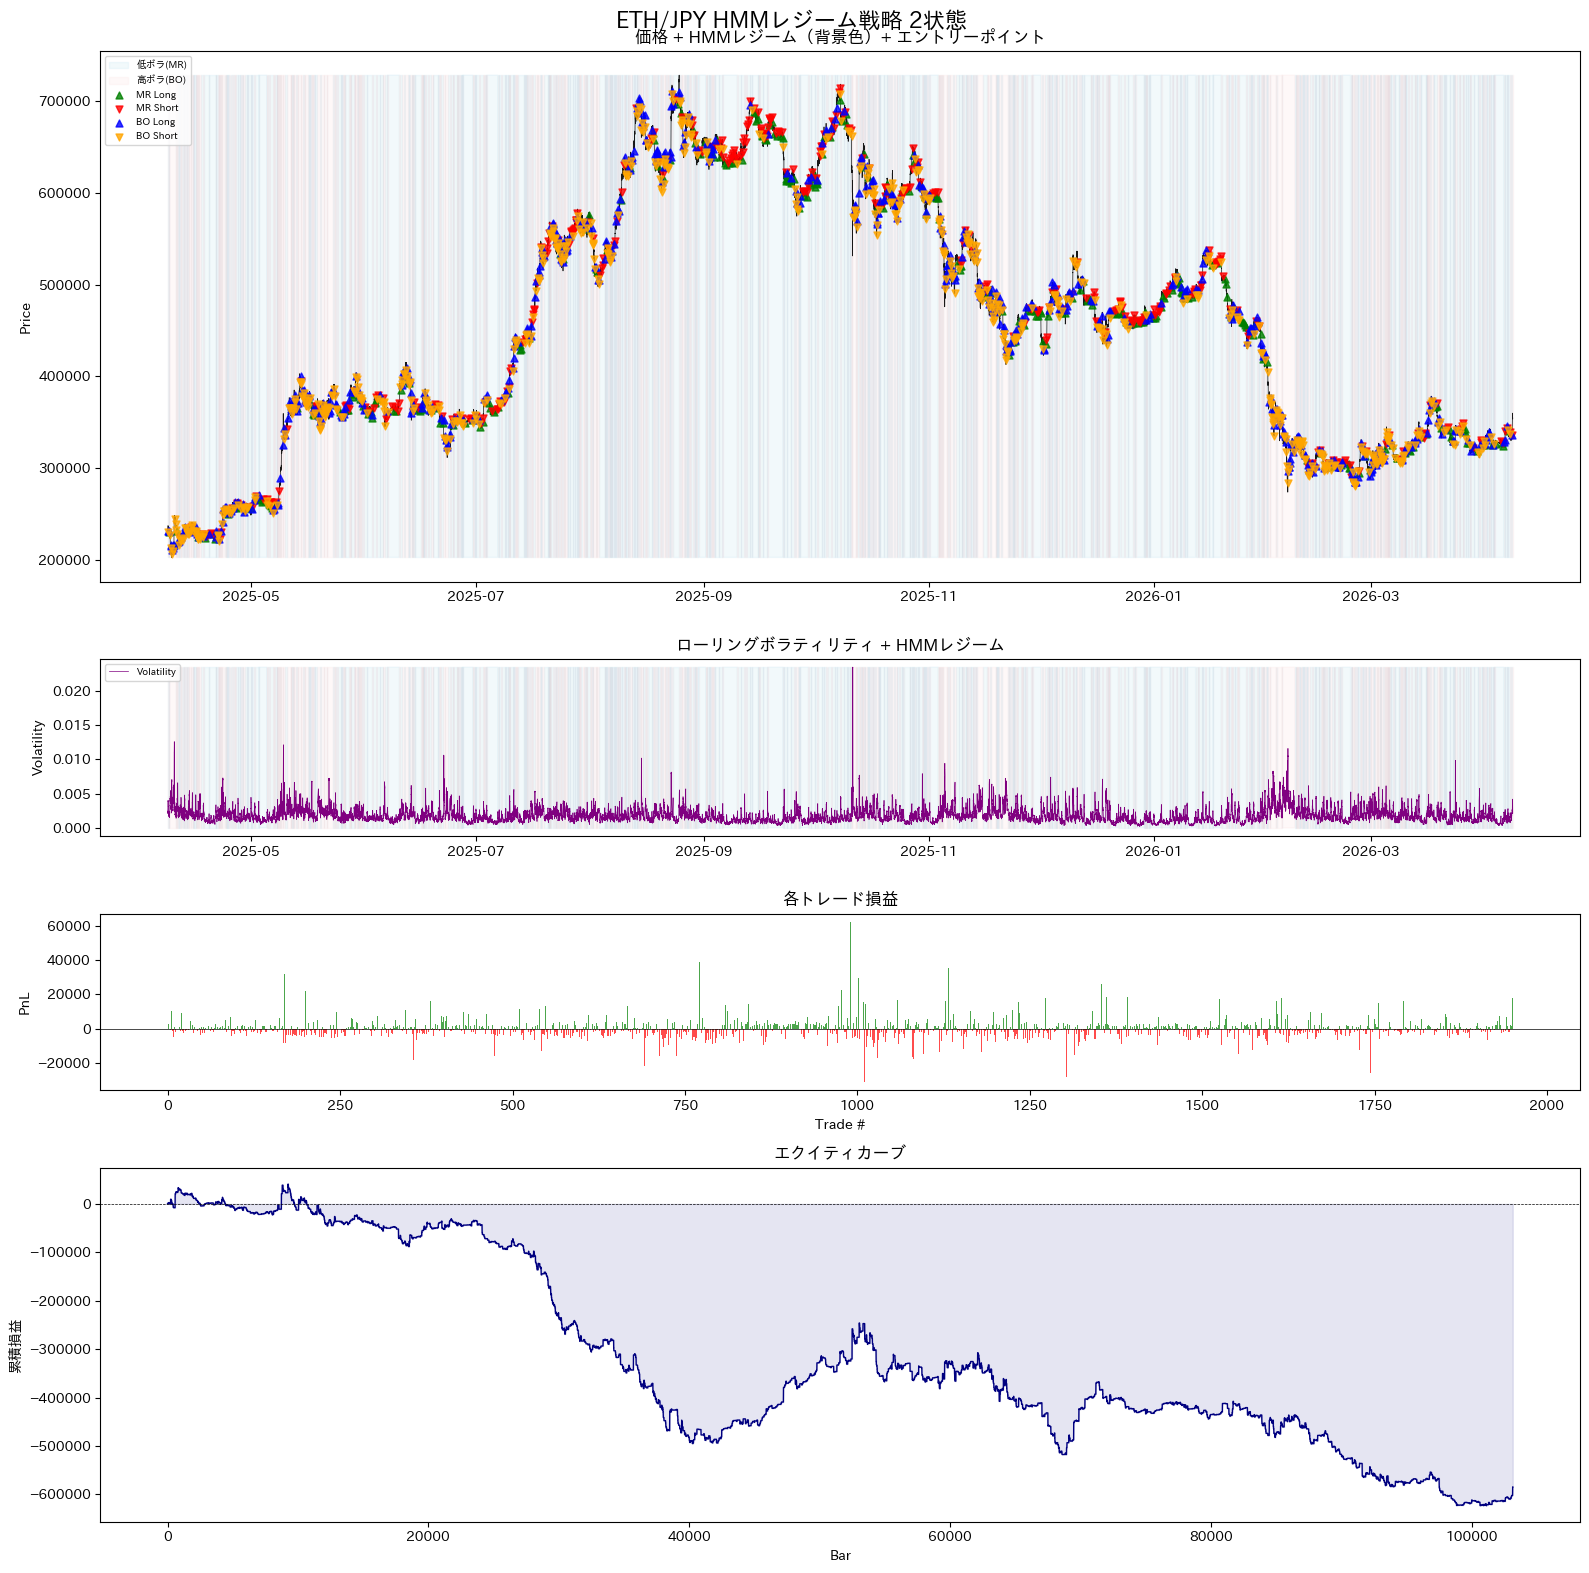

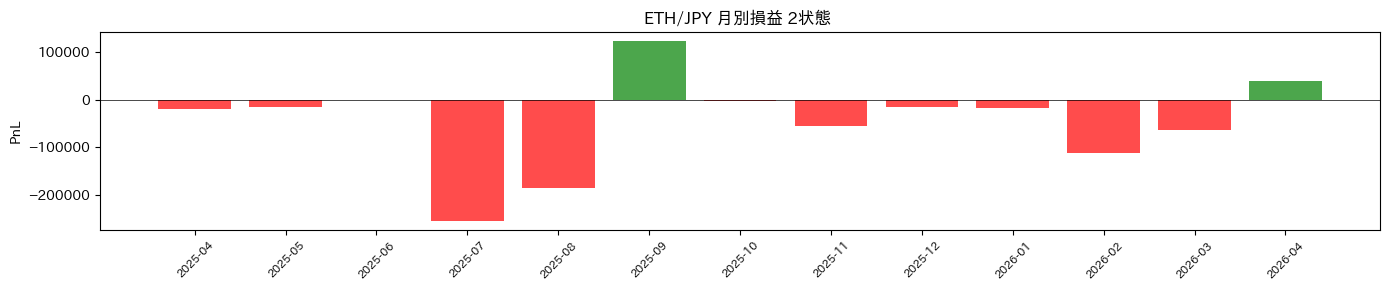

In [18]:
plot_hmm_regime_results(results_eth_2, df_eth, "regime_2", n_states=2)

### ETH/JPY 結果（3状態）

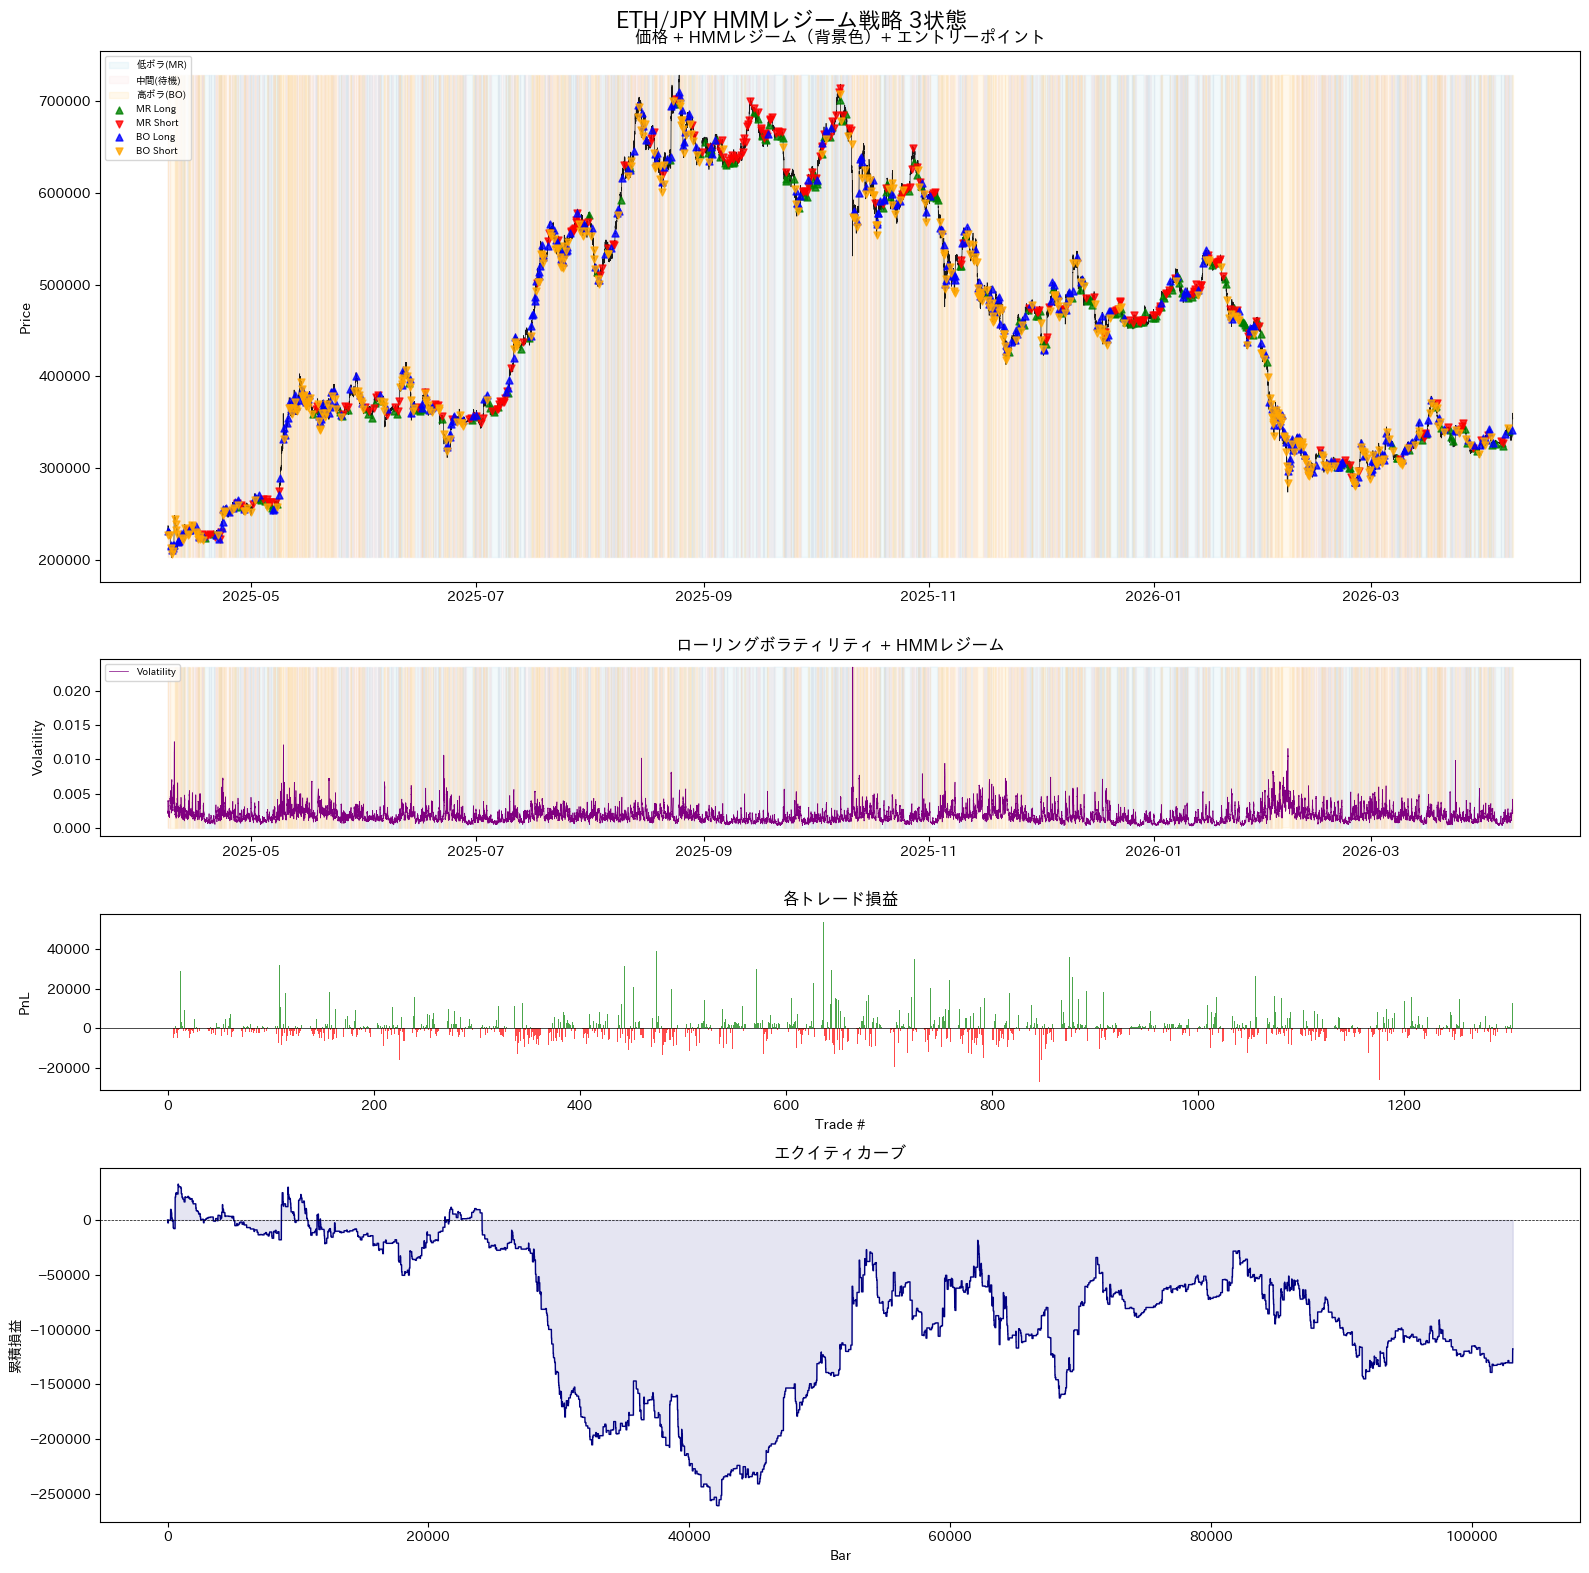

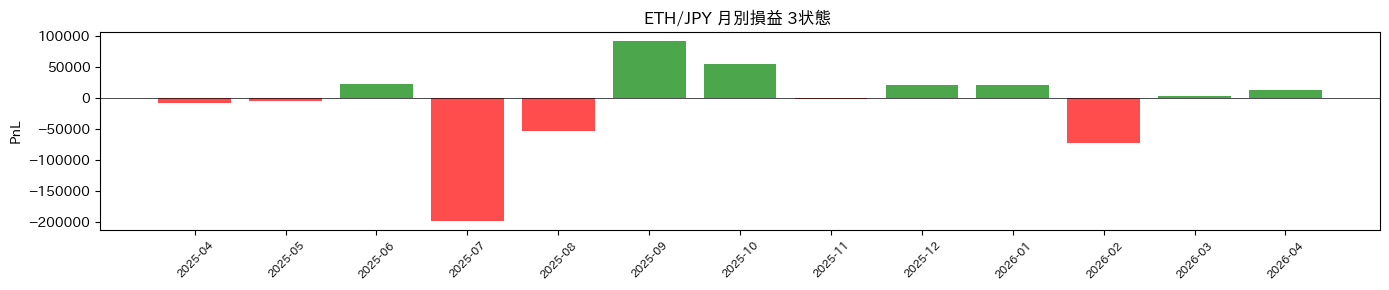

In [19]:
plot_hmm_regime_results(results_eth_3, df_eth, "regime_3", n_states=3)

## 7. 比較サマリー（2状態 vs 3状態 vs 第4弾ADX）

In [20]:
# 第4弾ADXデフォルト結果（参照用）
ADX_RESULTS = {
    "USD/JPY": {"total_trades": 1356, "win_rate": 44.6, "total_pnl": -20.812,  "profit_factor": 0.827, "max_drawdown": -21.672},
    "ETH/JPY": {"total_trades": 1829, "win_rate": 44.5, "total_pnl": -471640.7, "profit_factor": 0.852, "max_drawdown": -489137.6},
}

def print_full_summary(res_2, res_3, symbol, unit=""):
    adx = ADX_RESULTS[symbol]
    print(f"\n{'='*70}")
    print(f"{symbol} 比較サマリー（HMM 2状態 vs 3状態 vs 第4弾ADX）")
    print(f"{'='*70}")

    rows = [
        ("第4弾 ADXデフォルト",   adx["total_trades"],    "-",  "-",  adx["win_rate"],
         adx["total_pnl"],        adx["profit_factor"],   adx["max_drawdown"]),
    ]
    if res_2["total_trades"] > 0:
        rows.append(("HMM 2状態", res_2["total_trades"],
                     res_2["mean_rev_trades"], res_2["breakout_trades"],
                     res_2["win_rate"], res_2["total_pnl"],
                     res_2["profit_factor"], res_2["max_drawdown"]))
    if res_3["total_trades"] > 0:
        rows.append(("HMM 3状態", res_3["total_trades"],
                     res_3["mean_rev_trades"], res_3["breakout_trades"],
                     res_3["win_rate"], res_3["total_pnl"],
                     res_3["profit_factor"], res_3["max_drawdown"]))

    for label, trades, mr, bo, wr, pnl, pf, dd in rows:
        mr_bo = f"(MR:{mr} / BO:{bo})" if mr != "-" else ""
        print(f"  [{label}]")
        print(f"    トレード数: {trades} {mr_bo}")
        print(f"    勝率: {wr:.1f}%  総損益: {pnl:.4f}{unit}  PF: {pf:.3f}  最大DD: {dd:.4f}{unit}")

    print(f"{'='*70}")
    print("* HMM結果はin-sampleの学習データで検証した結果。")


print_full_summary(results_usdjpy_2, results_usdjpy_3, "USD/JPY", unit="円")
print_full_summary(results_eth_2,    results_eth_3,    "ETH/JPY", unit="円")


USD/JPY 比較サマリー（HMM 2状態 vs 3状態 vs 第4弾ADX）
  [第4弾 ADXデフォルト]
    トレード数: 1356 
    勝率: 44.6%  総損益: -20.8120円  PF: 0.827  最大DD: -21.6720円
  [HMM 2状態]
    トレード数: 1390 (MR:642 / BO:748)
    勝率: 49.9%  総損益: -12.5860円  PF: 0.905  最大DD: -18.8810円
  [HMM 3状態]
    トレード数: 945 (MR:435 / BO:510)
    勝率: 51.5%  総損益: -2.1330円  PF: 0.976  最大DD: -11.7950円
* HMM結果はin-sampleの学習データで検証した結果。

ETH/JPY 比較サマリー（HMM 2状態 vs 3状態 vs 第4弾ADX）
  [第4弾 ADXデフォルト]
    トレード数: 1829 
    勝率: 44.5%  総損益: -471640.7000円  PF: 0.852  最大DD: -489137.6000円
  [HMM 2状態]
    トレード数: 1951 (MR:708 / BO:1243)
    勝率: 45.3%  総損益: -584331.5259円  PF: 0.844  最大DD: -663840.3435円
  [HMM 3状態]
    トレード数: 1306 (MR:474 / BO:832)
    勝率: 48.0%  総損益: -117426.9707円  PF: 0.954  最大DD: -293401.8126円
* HMM結果はin-sampleの学習データで検証した結果。
